# Spotify XAI Analysis

End-to-end pipeline: EDA → Modeling → Explainability (PDP,ICE,PFI)

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm joblib tabulate nbformat ipykernel lime



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Section 0: Setup

In [2]:
import sys
import os

sys.path.insert(0, '../src')

import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt

from utils import ensure_dirs, set_plot_style, print_section, save_figure
from preprocessing import (
    load_and_clean, distribution_analysis,
    correlation_with_popularity, bias_check, engineer_features,
)
from modeling import (
    split_data, train_all_models, evaluate_models,
    run_isolation_forest, save_models,
)
from pdp_ice import (
    select_pdp_features,
    plot_pdp_grid,
    plot_ice_grid,
    pdp_ice_interpretation_table,
)
from pfi import run_pfi_analysis

from lime_model import (
    make_lime_explainer,
    explain_single_instance_lime,
    lime_explanation_to_df,
    plot_lime_explanation
)

ensure_dirs('../outputs')
set_plot_style()
print("Setup complete.")


Setup complete.


## Section 1: Phase 1 — Data Loading and EDA

### 1.1 Load and Clean

In [3]:
df = load_and_clean('../dataset.csv')


  Data Loading & Cleaning

Loaded: 114000 rows, 20 columns
Dropped 24259 duplicate track_ids
Dropped 0 null popularity rows
Converted 'explicit' to int. Final shape: (89741, 20)

Remaining nulls:
artists       1
album_name    1
track_name    1
dtype: int64


### 1.2 Distribution Analysis

Histograms and boxplots reveal the spread and skewness of each audio feature. Highly skewed features (|skew| > 1) may need transformation for linear models, though tree-based models are robust to skew.

In [4]:
distribution_analysis(df, '../outputs/figures')


  Distribution Analysis


Skewness Table (sorted descending):
         Feature  Skewness
     duration_ms 11.072075
     speechiness  4.545863
        explicit  2.956827
        liveness  2.062106
instrumentalness  1.564014
    acousticness  0.655741
           tempo  0.182728
         valence  0.127614
      popularity  0.070868
             key -0.000157
    danceability -0.398282
          energy -0.559989
            mode -0.569665
        loudness -1.959883
  time_signature -3.998837

High skew features (|skew| > 1): ['duration_ms', 'speechiness', 'explicit', 'liveness', 'instrumentalness', 'loudness', 'time_signature']


### 1.3 Correlation with Popularity

Pearson correlation shows linear relationships. Loudness and energy tend to have the strongest positive correlations with popularity — louder, energetic tracks are associated with mainstream appeal. Acousticness and instrumentalness often show negative correlation, reflecting a preference for vocal, produced sound in popular music.

In [5]:
correlation_with_popularity(df, '../outputs/figures')


  Correlation with Popularity


Top 5 positively correlated with popularity:
loudness          0.071676
danceability      0.064281
explicit          0.054902
time_signature    0.036893
energy            0.013728

Top 5 negatively correlated with popularity:
acousticness   -0.038847
duration_ms    -0.023119
mode           -0.016214
liveness       -0.013844
valence        -0.011526


### 1.4 Bias Check

Uneven genre representation can bias model predictions toward over-represented genres. Artists with many tracks may also skew the learned relationships between audio features and popularity.

In [6]:
bias_report = bias_check(df, '../outputs/figures')
print(bias_report)


  Bias Check

Genre imbalance ratio (max/min): 13.5x
No single artist dominates >1% of tracks.
{'genre_imbalance_ratio': 13.513513513513514, 'dominant_artists': []}


## Section 2: Phase 2 — Feature Engineering and Modeling

### 2.1 Feature Engineering

In [7]:
X, y, feature_names = engineer_features(df)
print(f"Features: {len(feature_names)}")
print(X.dtypes.value_counts())


  Feature Engineering

Feature matrix: 89741 rows × 126 features
Genre dummies created. Total features: 126
Features: 126
bool       112
float64      9
int64        5
Name: count, dtype: int64


### 2.2 Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = split_data(X, y)

Train: 71792 rows | Test: 17949 rows


### 2.3 Train All Models

We train four models: a linear baseline (LinearRegression), two ensemble tree models (RandomForest, XGBoost), and a gradient boosting model (LightGBM). Tree-based models are expected to capture non-linear audio feature interactions.

In [9]:
models_dict = train_all_models(X_train, y_train)


  Model Training

  linear   trained in 0.87s
  rf       trained in 12.77s
  xgb      trained in 1.16s
  lgbm     trained in 0.65s
[timer] train_all_models completed in 15.62s


### 2.4 Evaluate Models

RMSE measures prediction error in popularity units (0–100). R² indicates how much variance in popularity the model explains. Popularity is notoriously hard to predict from audio features alone — values of R² ~ 0.2–0.4 are typical for audio-only models.


Model Evaluation Results:
          RMSE     MAE     R2
Model                        
linear  16.845  12.008  0.321
rf      18.375  14.531  0.192
xgb     16.208  11.750  0.371
lgbm    16.229  11.798  0.369


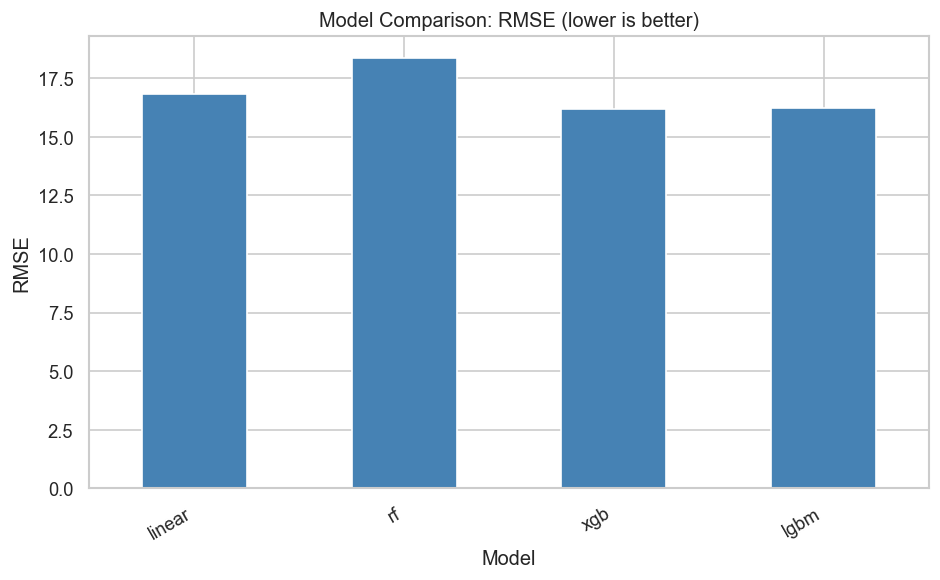

,RMSE,MAE,R2
Model,,,
linear,16.845,12.008,0.321
rf,18.375,14.531,0.192
xgb,16.208,11.750,0.371
lgbm,16.229,11.798,0.369


In [10]:
results_df = evaluate_models(models_dict, X_test, y_test)
results_df

### 2.5 Anomaly Detection — Isolation Forest

Isolation Forest flags tracks whose audio feature combinations are unusual compared to the rest of the dataset. These may be mislabelled tracks, niche experimental recordings, or data entry errors.

In [11]:
anomaly_labels, anomaly_scores = run_isolation_forest(X_train)
print(anomaly_scores.describe())



  Anomaly Detection — Isolation Forest

Anomalies detected: 3590 (5.0% of training data)
count    71792.000000
mean        -0.334965
std          0.013358
min         -0.424587
25%         -0.341200
50%         -0.332918
75%         -0.325892
max         -0.305905
Name: anomaly_score, dtype: float64


### 2.6 Save Models

In [12]:
save_models(models_dict, './outputs/models')

Saved linear → ./outputs/models\linear_model.joblib
Saved rf → ./outputs/models\rf_model.joblib
Saved xgb → ./outputs/models\xgb_model.joblib
Saved lgbm → ./outputs/models\lgbm_model.joblib


## Section 3: Phase 3 — PDP and ICE Analysis

Partial Dependence Plots (PDP) show the **average** effect of a single feature on predicted popularity, holding all other features constant. Individual Conditional Expectation (ICE) plots show this effect **per track** — diverging ICE lines reveal interaction effects where the feature's impact depends on other feature values.

We analyse RandomForest, XGBoost, and LightGBM. All three are non-linear models whose internal mechanisms are opaque — PDP/ICE provides post-hoc transparency.


### 3.1 Feature Selection

In [13]:
X_test_sample = X_test.sample(5000, random_state=42)
features = select_pdp_features(feature_names)
print("PDP/ICE features:", features)


PDP/ICE features: ['energy', 'danceability', 'loudness', 'acousticness', 'valence', 'tempo']


### 3.2 RandomForest — PDP Analysis

RandomForest is our primary model for explanation because its ensemble averaging produces stable, interpretable PDP curves.

In [14]:
# Partial Dependence Plots — RandomForest
plot_pdp_grid(models_dict['rf'], X_test_sample, features, 'RandomForest', '../outputs/figures')


In [15]:
# PDP/ICE interpretation table — RandomForest
rf_interp = pdp_ice_interpretation_table(models_dict['rf'], X_test_sample, features, 'RandomForest')
rf_interp



PDP/ICE Interpretation Table — RandomForest
     Feature  PDP Range     PDP Shape  ICE Heterogeneity (std)
      energy      0.461 non-monotonic                    4.804
danceability      0.103 non-monotonic                    1.227
    loudness      0.272 non-monotonic                    1.997
acousticness      0.383 non-monotonic                    3.029
     valence      0.067 non-monotonic                    1.422
       tempo      0.129 non-monotonic                    1.268


,Feature,PDP Range,PDP Shape,ICE Heterogeneity (std)
0,energy,0.461,non-monotonic,4.804
1,danceability,0.103,non-monotonic,1.227
2,loudness,0.272,non-monotonic,1.997
3,acousticness,0.383,non-monotonic,3.029
4,valence,0.067,non-monotonic,1.422
5,tempo,0.129,non-monotonic,1.268


### 3.3 RandomForest — ICE Analysis

ICE plots show the effect of each feature **per track** — diverging lines reveal interaction effects.

In [16]:
# ICE plots (standard) — RandomForest
plot_ice_grid(models_dict['rf'], X_test_sample, features, 'RandomForest', '../outputs/figures', centered=False)

In [17]:
# ICE plots (centered) — RandomForest
plot_ice_grid(models_dict['rf'], X_test_sample, features, 'RandomForest', '../outputs/figures', centered=True)


**Interpretation — RandomForest PDP/ICE:**

- **Loudness** typically shows a monotonic positive relationship with predicted popularity — the model has learned that louder (more heavily mastered) tracks tend to chart better, consistent with the loudness war in commercial music production.
- **Energy** also tends to show a positive association — high-energy tracks dominate streaming charts in pop, hip-hop, and electronic genres.
- **Acousticness** commonly shows a negative association — highly acoustic tracks (folk, classical) receive lower predicted popularity scores on average, reflecting the dataset's genre distribution.
- **Danceability** may show non-monotonic behaviour — moderate danceability scores align with the widest range of popular genres, while extremes (very low or very high) narrow genre appeal.
- **ICE heterogeneity** for loudness and energy is often high, indicating that the effect of these features depends on other characteristics — a loud acoustic ballad behaves differently from a loud electronic track.


### 3.4 XGBoost — PDP Analysis

XGBoost is our secondary model. Its gradient-boosted trees can capture sharper feature thresholds. Comparing RF and XGBoost PDPs reveals whether the learned relationships are consistent across model architectures.

In [18]:
# Partial Dependence Plots — XGBoost
plot_pdp_grid(models_dict['xgb'], X_test_sample, features, 'XGBoost', '../outputs/figures')


In [19]:
# PDP/ICE interpretation table — XGBoost
xgb_interp = pdp_ice_interpretation_table(models_dict['xgb'], X_test_sample, features, 'XGBoost')
xgb_interp



PDP/ICE Interpretation Table — XGBoost
     Feature  PDP Range     PDP Shape  ICE Heterogeneity (std)
      energy      2.061 non-monotonic                    3.599
danceability      1.469 non-monotonic                    3.761
    loudness      0.923 non-monotonic                    3.076
acousticness      3.882 non-monotonic                    3.260
     valence      2.076 non-monotonic                    2.594
       tempo      0.201 non-monotonic                    2.718


,Feature,PDP Range,PDP Shape,ICE Heterogeneity (std)
0,energy,2.061,non-monotonic,3.599
1,danceability,1.469,non-monotonic,3.761
2,loudness,0.923,non-monotonic,3.076
3,acousticness,3.882,non-monotonic,3.260
4,valence,2.076,non-monotonic,2.594
5,tempo,0.201,non-monotonic,2.718


### 3.5 XGBoost — ICE Analysis

In [20]:
# ICE plots (standard) — XGBoost
plot_ice_grid(models_dict['xgb'], X_test_sample, features, 'XGBoost', '../outputs/figures', centered=False)


In [21]:
# ICE plots (centered) — XGBoost
plot_ice_grid(models_dict['xgb'], X_test_sample, features, 'XGBoost', '../outputs/figures', centered=True)


**Interpretation — XGBoost PDP/ICE:**

- XGBoost PDPs often show **sharper transitions** than RandomForest — gradient boosting captures hard decision boundaries that manifest as step-like PDP curves, particularly for loudness and tempo.
- Where RF and XGBoost agree on the direction of an effect (e.g. both show loudness positively correlated with popularity), that finding is more robust — it is not an artefact of a single model's inductive bias.
- Discrepancies between the two models in the shape of the tempo PDP may reflect that tempo's effect on popularity is highly context-dependent (genre-mediated), making it sensitive to the model's feature interaction capacity.
- High ICE heterogeneity in XGBoost valence plots suggests the model has captured that the emotional tone of a track (valence) affects different subsets of songs differently — happy-sounding tracks benefit in pop contexts but not in hip-hop.


### 3.6 LightGBM — PDP Analysis

LightGBM is also a gradient boosting model but uses leaf-wise tree growth rather than XGBoost's level-wise approach, which can produce different decision boundaries and feature interaction patterns.

In [22]:
# Partial Dependence Plots — LightGBM
plot_pdp_grid(models_dict['lgbm'], X_test_sample, features, 'LightGBM', '../outputs/figures')


In [23]:
# PDP/ICE interpretation table — LightGBM
lgbm_interp = pdp_ice_interpretation_table(models_dict['lgbm'], X_test_sample, features, 'LightGBM')
lgbm_interp



PDP/ICE Interpretation Table — LightGBM
     Feature  PDP Range     PDP Shape  ICE Heterogeneity (std)
      energy      2.193 non-monotonic                    2.075
danceability      1.901 non-monotonic                    2.339
    loudness      1.232 non-monotonic                    2.337
acousticness      3.643 non-monotonic                    2.648
     valence      2.051 non-monotonic                    1.731
       tempo      0.255 non-monotonic                    1.430


,Feature,PDP Range,PDP Shape,ICE Heterogeneity (std)
0,energy,2.193,non-monotonic,2.075
1,danceability,1.901,non-monotonic,2.339
2,loudness,1.232,non-monotonic,2.337
3,acousticness,3.643,non-monotonic,2.648
4,valence,2.051,non-monotonic,1.731
5,tempo,0.255,non-monotonic,1.430


### 3.7 LightGBM — ICE Analysis

In [24]:
# ICE plots (standard) — LightGBM
plot_ice_grid(models_dict['lgbm'], X_test_sample, features, 'LightGBM', '../outputs/figures', centered=False)


In [25]:
# ICE plots (centered) — LightGBM
plot_ice_grid(models_dict['lgbm'], X_test_sample, features, 'LightGBM', '../outputs/figures', centered=True)


**Interpretation — LightGBM PDP/ICE:**

- LightGBM's **leaf-wise growth** can produce sharper, more irregular PDP curves than XGBoost's level-wise approach — features like loudness and energy may show more abrupt transitions.
- Where all three models (RF, XGBoost, LightGBM) agree on the direction of an effect, that finding is robust across different inductive biases.
- **ICE heterogeneity** in LightGBM may differ from XGBoost on the same features — comparing the two gradient boosting models reveals whether interaction effects are a property of the data or an artefact of the specific boosting algorithm.
- LightGBM is generally faster to train than XGBoost on large datasets, making it practical for repeated explainability analyses.


## Section 4 — Permutation Feature Importance (PFI)

- PFI measures how much model performance drops when a feature is randomly shuffled.
- If shuffling a feature causes a large drop, the model relies strongly on that feature.

In [26]:
from pfi import run_pfi_analysis
pfi_results = run_pfi_analysis(
    models_dict=models_dict,
    X_test=X_test,
    y_test=y_test,
    output_dir='../outputs/figures',
    scoring='r2',
    n_repeats=10,
    top_n=15,
    model_keys=['rf', 'xgb', 'lgbm'],
    run_standard=True,
    run_grouped=True,
)


  Permutation Feature Importance — RandomForest


Top 15 features by standard PFI (r2) — RandomForest
                   Feature  Importance Mean  Importance Std
       track_genre_iranian         0.057397        0.002125
       track_genre_romance         0.039797        0.001658
         track_genre_k-pop         0.026177        0.001407
      track_genre_pop-film         0.023808        0.000955
         track_genre_latin         0.023687        0.001485
 track_genre_chicago-house         0.022648        0.000808
          track_genre_kids         0.019956        0.001293
           track_genre_idm         0.019816        0.000842
track_genre_detroit-techno         0.019209        0.001387
     track_genre_grindcore         0.018997        0.000856
         track_genre_chill         0.016469        0.001096
    track_genre_honky-tonk         0.016342        0.001353
          track_genre_jazz         0.015591        0.000789
       track_genre_country         0.012752        0.0008

### 4.1 Random Forest — PFI Analysis

- The Random Forest model’s standard PFI results show that individual genre dummy variables dominate the importance rankings, indicating that the model relies heavily on genre-specific splits to predict popularity. However, this fragmented importance is clarified through grouped PFI, where the entire genre block emerges as overwhelmingly dominant, with a substantially larger impact than any individual audio feature. This confirms that the model is primarily driven by categorical segmentation rather than intrinsic musical attributes.

- Beyond genre, audio features such as acousticness, energy, instrumentalness, and duration contribute marginally to predictive performance, but their impact is significantly smaller compared to the grouped genre effect. This suggests that while the model captures some signal from musical characteristics, these features play a secondary role in decision-making.

- Overall, the Random Forest model appears to over-rely on genre information, likely influenced by dataset-level genre imbalance. This limits its ability to generalize based on underlying audio properties, highlighting a potential bias toward categorical features rather than deeper musical patterns.

### 4.2 XGBoost — PFI Analysis

- The XGBoost model demonstrates a more balanced feature importance structure compared to Random Forest. While standard PFI still highlights genre variables prominently, grouped PFI reveals that genre remains the most influential feature group, with a substantial impact on model performance. However, the relative dominance of genre is complemented by meaningful contributions from several audio features.

- Features such as duration, acousticness, instrumentalness, loudness, and energy show significant importance, indicating that XGBoost effectively captures nonlinear relationships between musical attributes and popularity. This suggests that the model goes beyond simple categorical segmentation and incorporates nuanced audio-based signals.

- Overall, XGBoost achieves a better balance between genre and audio features, making it more robust and interpretable. The model indicates that while genre provides a strong baseline signal, intrinsic musical characteristics play a crucial role in refining predictions within genres.

### 4.3 LightGBM — PFI Analysis

- The LightGBM model exhibits a pattern similar to XGBoost, reinforcing the consistency of the findings across boosting-based approaches. Standard PFI again highlights genre variables individually, while grouped PFI clearly establishes genre as the most dominant feature group, with a large impact on model performance.

- In addition to genre, several audio features—including acousticness, duration, loudness, instrumentalness, danceability, and energy—contribute meaningfully to predictions. This indicates that LightGBM effectively leverages both categorical and continuous features, capturing complex interactions between musical attributes and popularity.

- The consistency between LightGBM and XGBoost suggests that these relationships are robust and not model-specific. Overall, LightGBM demonstrates strong capability in combining genre-level patterns with detailed audio feature signals, providing a more comprehensive understanding of the drivers of track popularity.

## Section 5: Leave One Covariate Out (LOCO)

LOCO (Leave-One-Covariate-Out) measures feature importance by removing one feature at a time, retraining the same model, and measuring the deterioration in predictive performance.

A larger increase in RMSE or MAE, or a larger drop in R², indicates that the removed feature was more important for predicting Spotify track popularity.

In [27]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

In [28]:
def get_loco_model(model_name: str):
    """
    Rebuild the same model architecture used in training so that LOCO
    can retrain from scratch after dropping each feature.
    """
    if model_name == 'linear':
        return LinearRegression()

    elif model_name == 'ridge':
        return Ridge(alpha=1.0)

    elif model_name == 'rf':
        return RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            n_jobs=-1,
            random_state=42
        )

    elif model_name == 'extra_trees':
        return ExtraTreesRegressor(
            n_estimators=100,
            max_depth=15,
            n_jobs=-1,
            random_state=42
        )

    elif model_name == 'xgb':
        return XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            n_jobs=-1,
            random_state=42,
            verbosity=0
        )

    elif model_name == 'lgbm':
        return LGBMRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            n_jobs=-1,
            random_state=42,
            verbose=-1
        )

    else:
        raise ValueError(f"Unsupported model name: {model_name}")

In [29]:
def loco_metrics(model, X_eval, y_eval) -> dict:
    """
    Compute regression metrics for LOCO evaluation.
    """
    preds = model.predict(X_eval)
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_eval, preds))),
        'MAE': float(mean_absolute_error(y_eval, preds)),
        'R2': float(r2_score(y_eval, preds))
    }

In [30]:
def run_loco_analysis(model_name: str, X_train, X_test, y_train, y_test) -> tuple:
    """
    Run LOCO by dropping one feature at a time, retraining the model,
    and comparing the deterioration in performance relative to baseline.
    """
    print_section(f"LOCO Analysis — {model_name}")

    baseline_model = get_loco_model(model_name)
    baseline_model.fit(X_train, y_train)
    baseline_metrics = loco_metrics(baseline_model, X_test, y_test)

    print("Baseline metrics:")
    print(baseline_metrics)

    rows = []

    for feature in X_train.columns:
        X_train_drop = X_train.drop(columns=[feature])
        X_test_drop = X_test.drop(columns=[feature])

        model = get_loco_model(model_name)
        model.fit(X_train_drop, y_train)

        dropped_metrics = loco_metrics(model, X_test_drop, y_test)

        rows.append({
            'feature_removed': feature,
            'baseline_RMSE': baseline_metrics['RMSE'],
            'baseline_MAE': baseline_metrics['MAE'],
            'baseline_R2': baseline_metrics['R2'],
            'new_RMSE': dropped_metrics['RMSE'],
            'new_MAE': dropped_metrics['MAE'],
            'new_R2': dropped_metrics['R2'],
            'delta_RMSE': dropped_metrics['RMSE'] - baseline_metrics['RMSE'],
            'delta_MAE': dropped_metrics['MAE'] - baseline_metrics['MAE'],
            'delta_R2': baseline_metrics['R2'] - dropped_metrics['R2']
        })

    loco_results = (
        pd.DataFrame(rows)
        .sort_values('delta_RMSE', ascending=False)
        .reset_index(drop=True)
    )

    return loco_results, baseline_metrics

In [31]:
def run_grouped_loco_for_genre(model_name: str, X_train, X_test, y_train, y_test):
    """
    Since track_genre is one-hot encoded into multiple columns, this grouped LOCO
    removes all genre dummy columns together to estimate the overall effect of genre.
    """
    print_section(f"Grouped LOCO for Genre — {model_name}")

    genre_cols = [c for c in X_train.columns if c.startswith('track_genre_')]

    if len(genre_cols) == 0:
        print("No genre dummy columns found.")
        return None

    baseline_model = get_loco_model(model_name)
    baseline_model.fit(X_train, y_train)
    baseline_metrics = loco_metrics(baseline_model, X_test, y_test)

    X_train_drop = X_train.drop(columns=genre_cols)
    X_test_drop = X_test.drop(columns=genre_cols)

    model = get_loco_model(model_name)
    model.fit(X_train_drop, y_train)

    dropped_metrics = loco_metrics(model, X_test_drop, y_test)

    grouped_result = pd.DataFrame([{
        'group_removed': 'track_genre_all_dummies',
        'n_columns_removed': len(genre_cols),
        'baseline_RMSE': baseline_metrics['RMSE'],
        'baseline_MAE': baseline_metrics['MAE'],
        'baseline_R2': baseline_metrics['R2'],
        'new_RMSE': dropped_metrics['RMSE'],
        'new_MAE': dropped_metrics['MAE'],
        'new_R2': dropped_metrics['R2'],
        'delta_RMSE': dropped_metrics['RMSE'] - baseline_metrics['RMSE'],
        'delta_MAE': dropped_metrics['MAE'] - baseline_metrics['MAE'],
        'delta_R2': baseline_metrics['R2'] - dropped_metrics['R2']
    }])

    return grouped_result

In [32]:
def run_grouped_loco_for_genre(model_name: str, X_train, X_test, y_train, y_test):
    """
    Since track_genre is one-hot encoded into multiple columns, this grouped LOCO
    removes all genre dummy columns together to estimate the overall effect of genre.
    """
    print_section(f"Grouped LOCO for Genre — {model_name}")

    genre_cols = [c for c in X_train.columns if c.startswith('track_genre_')]

    if len(genre_cols) == 0:
        print("No genre dummy columns found.")
        return None

    baseline_model = get_loco_model(model_name)
    baseline_model.fit(X_train, y_train)
    baseline_metrics = loco_metrics(baseline_model, X_test, y_test)

    X_train_drop = X_train.drop(columns=genre_cols)
    X_test_drop = X_test.drop(columns=genre_cols)

    model = get_loco_model(model_name)
    model.fit(X_train_drop, y_train)

    dropped_metrics = loco_metrics(model, X_test_drop, y_test)

    grouped_result = pd.DataFrame([{
        'group_removed': 'track_genre_all_dummies',
        'n_columns_removed': len(genre_cols),
        'baseline_RMSE': baseline_metrics['RMSE'],
        'baseline_MAE': baseline_metrics['MAE'],
        'baseline_R2': baseline_metrics['R2'],
        'new_RMSE': dropped_metrics['RMSE'],
        'new_MAE': dropped_metrics['MAE'],
        'new_R2': dropped_metrics['R2'],
        'delta_RMSE': dropped_metrics['RMSE'] - baseline_metrics['RMSE'],
        'delta_MAE': dropped_metrics['MAE'] - baseline_metrics['MAE'],
        'delta_R2': baseline_metrics['R2'] - dropped_metrics['R2']
    }])

    return grouped_result

### 5.1 Select the best model for LOCO

LOCO is applied to the most accurate model, selected using the lowest RMSE on the test set.

In [33]:
best_model_name = results_df['RMSE'].idxmin()
print("Best model selected for LOCO:", best_model_name)

Best model selected for LOCO: xgb


### 5.2 Run LOCO analysis

In [34]:
loco_results, baseline_metrics = run_loco_analysis(
    best_model_name,
    X_train,
    X_test,
    y_train,
    y_test
)

loco_results.head(20)


  LOCO Analysis — xgb

Baseline metrics:
{'RMSE': 16.20801178417926, 'MAE': 11.749757766723633, 'R2': 0.37106651067733765}


,feature_removed,baseline_RMSE,baseline_MAE,baseline_R2,new_RMSE,new_MAE,new_R2,delta_RMSE,delta_MAE,delta_R2
0,track_genre_iranian,16.208012,11.749758,0.371067,16.424340,11.986935,0.354166,0.216328,0.237177,0.016901
1,track_genre_latin,16.208012,11.749758,0.371067,16.361994,11.894884,0.359060,0.153982,0.145126,0.012007
2,track_genre_pop-film,16.208012,11.749758,0.371067,16.359028,11.898715,0.359292,0.151016,0.148957,0.011775
3,track_genre_romance,16.208012,11.749758,0.371067,16.341940,11.930215,0.360630,0.133928,0.180457,0.010437
4,track_genre_k-pop,16.208012,11.749758,0.371067,16.339808,11.871895,0.360797,0.131796,0.122137,0.010270
5,track_genre_chicago-house,16.208012,11.749758,0.371067,16.307166,11.903560,0.363348,0.099155,0.153802,0.007719
6,track_genre_kids,16.208012,11.749758,0.371067,16.297617,11.887275,0.364093,0.089605,0.137517,0.006973
7,track_genre_chill,16.208012,11.749758,0.371067,16.294994,11.853929,0.364298,0.086982,0.104171,0.006769
8,track_genre_idm,16.208012,11.749758,0.371067,16.290925,11.848288,0.364615,0.082913,0.098530,0.006451
9,track_genre_hip-hop,16.208012,11.749758,0.371067,16.290685,11.827426,0.364634,0.082673,0.077668,0.006432


### 5.3 Visualise LOCO feature importance

Features are ranked by the increase in RMSE after removal. A larger increase indicates greater importance.

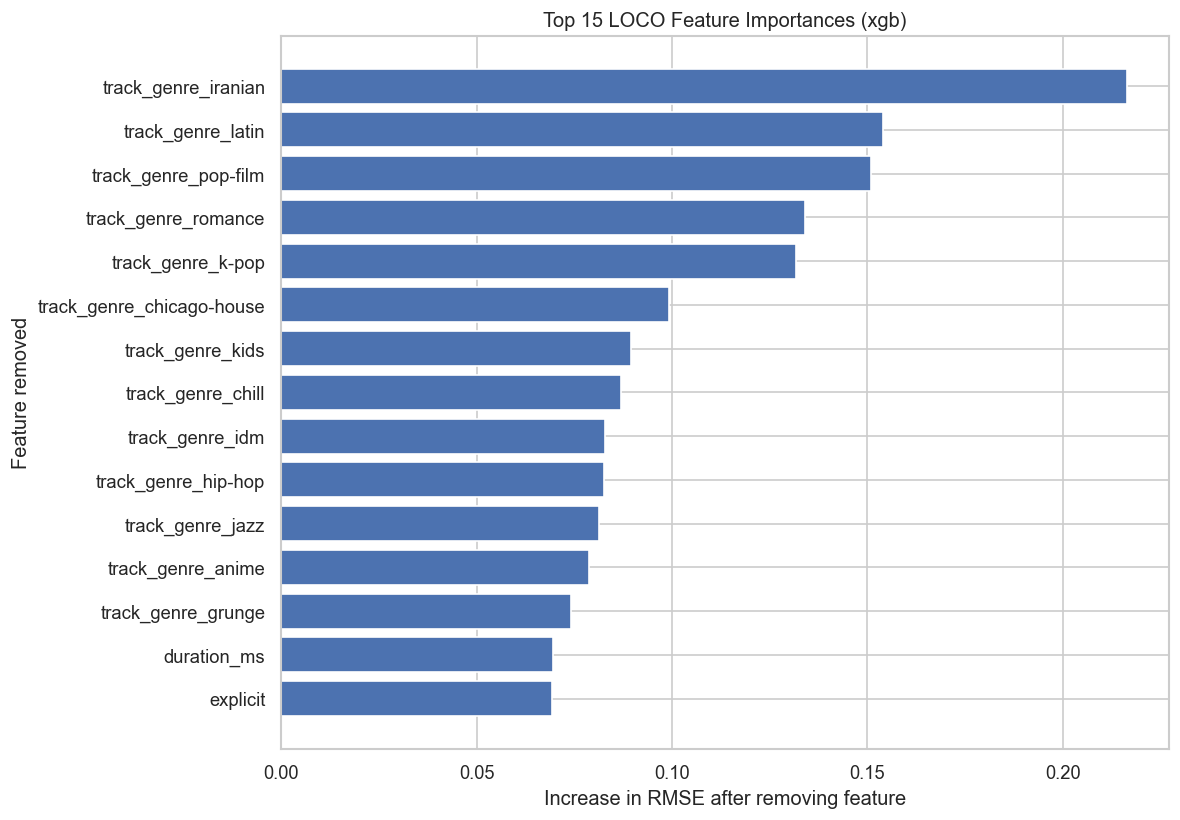

In [35]:
top_n = 15
plot_df = loco_results.head(top_n).sort_values('delta_RMSE', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['feature_removed'], plot_df['delta_RMSE'])
ax.set_xlabel('Increase in RMSE after removing feature')
ax.set_ylabel('Feature removed')
ax.set_title(f'Top {top_n} LOCO Feature Importances ({best_model_name})')

plt.tight_layout()
plt.show()

### 5.4 Grouped LOCO for genre

Since `track_genre` was one-hot encoded into multiple dummy variables, removing one dummy at a time may understate the total effect of genre. To address this, we remove all genre dummy columns together and measure the resulting deterioration in model performance.

In [36]:
grouped_loco_result = run_grouped_loco_for_genre(
    best_model_name,
    X_train,
    X_test,
    y_train,
    y_test
)

grouped_loco_result


  Grouped LOCO for Genre — xgb



,group_removed,n_columns_removed,baseline_RMSE,baseline_MAE,baseline_R2,new_RMSE,new_MAE,new_R2,delta_RMSE,delta_MAE,delta_R2
0,track_genre_all_dummies,112,16.208012,11.749758,0.371067,18.671841,14.857453,0.165321,2.463829,3.107696,0.205746


### 5.5 Summary table

The table below reports the deterioration in model performance after removing each feature. Features with larger increases in RMSE or MAE, or larger drops in R², are considered more important.

In [37]:
summary_table = loco_results[[
    'feature_removed',
    'delta_RMSE',
    'delta_MAE',
    'delta_R2'
]].copy()

summary_table['importance_rank'] = range(1, len(summary_table) + 1)

summary_table.head(20)

,feature_removed,delta_RMSE,delta_MAE,delta_R2,importance_rank
0,track_genre_iranian,0.216328,0.237177,0.016901,1
1,track_genre_latin,0.153982,0.145126,0.012007,2
2,track_genre_pop-film,0.151016,0.148957,0.011775,3
3,track_genre_romance,0.133928,0.180457,0.010437,4
4,track_genre_k-pop,0.131796,0.122137,0.010270,5
5,track_genre_chicago-house,0.099155,0.153802,0.007719,6
6,track_genre_kids,0.089605,0.137517,0.006973,7
7,track_genre_chill,0.086982,0.104171,0.006769,8
8,track_genre_idm,0.082913,0.098530,0.006451,9
9,track_genre_hip-hop,0.082673,0.077668,0.006432,10


### 5.6 Top and bottom features

To make the interpretation easier, we separately inspect the most important and least important features based on LOCO.

In [38]:
print("Top 10 most important features based on LOCO:")
display(summary_table.head(10))

print("Bottom 10 least important features based on LOCO:")
display(summary_table.tail(10))

Top 10 most important features based on LOCO:


,feature_removed,delta_RMSE,delta_MAE,delta_R2,importance_rank
0,track_genre_iranian,0.216328,0.237177,0.016901,1
1,track_genre_latin,0.153982,0.145126,0.012007,2
2,track_genre_pop-film,0.151016,0.148957,0.011775,3
3,track_genre_romance,0.133928,0.180457,0.010437,4
4,track_genre_k-pop,0.131796,0.122137,0.010270,5
5,track_genre_chicago-house,0.099155,0.153802,0.007719,6
6,track_genre_kids,0.089605,0.137517,0.006973,7
7,track_genre_chill,0.086982,0.104171,0.006769,8
8,track_genre_idm,0.082913,0.098530,0.006451,9
9,track_genre_hip-hop,0.082673,0.077668,0.006432,10


Bottom 10 least important features based on LOCO:


,feature_removed,delta_RMSE,delta_MAE,delta_R2,importance_rank
116,track_genre_disney,-0.020022,0.011721,-0.001553,117
117,track_genre_folk,-0.021002,-0.006326,-0.001629,118
118,track_genre_r-n-b,-0.021337,-0.003866,-0.001655,119
119,track_genre_indie-pop,-0.022632,-0.014838,-0.001755,120
120,track_genre_malay,-0.027509,0.004404,-0.002133,121
121,mode,-0.029466,-0.016191,-0.002285,122
122,track_genre_comedy,-0.032303,-0.009808,-0.002504,123
123,liveness,-0.032580,-0.006126,-0.002526,124
124,track_genre_punk-rock,-0.033622,-0.013050,-0.002607,125
125,track_genre_forro,-0.049225,-0.002199,-0.003814,126


### 5.7 Interpretation

LOCO measures how much the model depends on each feature for prediction.

- Features with larger increases in RMSE after removal are more important.
- Features with minimal change in RMSE are less influential.
- For one-hot encoded variables such as genre, grouped removal provides a more complete view of their total contribution.

## Section 6 — Local Interpretable Model-Agnostic Explanations (LIME)

- LIME is a post-training interpretability method that explains an individual prediction made by any trained 'black-box' model by approximating its behavior locally with a simple, interpretable (glass-box) model
- It works by perturbing the input around one data point and observing how the model's prediction changes, so we can see which features contributed most to that specific prediction

In [39]:
print("LIME sample size:", X_test_sample.shape)

LIME sample size: (5000, 126)


In [40]:
def to_float_df(X):
    X2 = X.copy()
    bool_cols = X2.select_dtypes(include=['bool']).columns
    if len(bool_cols) > 0:
        X2[bool_cols] = X2[bool_cols].astype(int)
    X2 = X2.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
    return X2

X_train = to_float_df(X_train)
X_test = to_float_df(X_test)
X_test_sample = to_float_df(X_test.sample(5000, random_state=42))

lime_explainer = make_lime_explainer(X_train)

In [41]:
def display_lime_summary(exp, model_key, data_index, pred_value, true_value, top_n=8):
    lime_df = lime_explanation_to_df(exp).head(top_n).copy()

    print(f"{model_key.upper()} | Sample index: {data_index}")
    print(f"Predicted popularity: {pred_value:.2f}")
    print(f"Actual popularity: {true_value:.2f}")
    display(lime_df[['feature', 'weight']])

In [42]:
sample_row_positions = [0, 1, 2]

for row_idx in sample_row_positions:
    sample_index = X_test_sample.index[row_idx]
    print("\n" + "=" * 100)
    print(f"Sample row position: {row_idx} | Original index: {sample_index}")

    for model_key in ['xgb', 'rf', 'lgbm']:
        model = models_dict[model_key]

        exp, instance, pred_value, true_value, data_index = explain_single_instance_lime(
            model=model,
            explainer=lime_explainer,
            X_data=X_test_sample,
            y_data=y_test,
            row_idx=row_idx,
            num_features=8
        )

        display_lime_summary(
            exp=exp,
            model_key=model_key,
            data_index=data_index,
            pred_value=pred_value,
            true_value=true_value,
            top_n=8
        )


Sample row position: 0 | Original index: 15346
XGB | Sample index: 15346
Predicted popularity: 52.65
Actual popularity: 0.00


,feature,weight
0,track_genre_iranian <= 0.00,29.180099
1,track_genre_romance <= 0.00,23.751932
2,track_genre_k-pop <= 0.00,-19.904196
3,track_genre_idm <= 0.00,15.760051
4,track_genre_detroit-techno <= 0.00,15.252474
5,track_genre_chicago-house <= 0.00,15.134084
6,track_genre_chill > 0.00,15.065590
7,track_genre_kids <= 0.00,14.001003


RF | Sample index: 15346
Predicted popularity: 48.63
Actual popularity: 0.00


,feature,weight
0,track_genre_iranian <= 0.00,30.003976
1,track_genre_romance <= 0.00,25.083141
2,track_genre_k-pop <= 0.00,-18.911724
3,track_genre_kids <= 0.00,17.878581
4,track_genre_idm <= 0.00,16.414123
5,track_genre_chill > 0.00,15.751717
6,track_genre_grindcore <= 0.00,15.270963
7,track_genre_chicago-house <= 0.00,15.249174


LGBM | Sample index: 15346
Predicted popularity: 52.49
Actual popularity: 0.00


...

,feature,weight
0,track_genre_iranian <= 0.00,28.356942
1,track_genre_romance <= 0.00,24.403256
2,track_genre_k-pop <= 0.00,-19.372803
3,track_genre_pop-film <= 0.00,-18.649396
4,track_genre_kids <= 0.00,16.805612
5,track_genre_chicago-house <= 0.00,16.208897
6,track_genre_latin <= 0.00,15.690191
7,track_genre_reggae <= 0.00,14.692733


RF | Sample index: 12819
Predicted popularity: 35.44
Actual popularity: 20.00


,feature,weight
0,track_genre_iranian <= 0.00,30.302673
1,track_genre_romance <= 0.00,24.792758
2,track_genre_k-pop <= 0.00,-19.546124
3,track_genre_pop-film <= 0.00,-18.734578
4,track_genre_kids <= 0.00,17.233463
5,track_genre_idm <= 0.00,16.500527
6,track_genre_grindcore <= 0.00,15.868556
7,track_genre_honky-tonk <= 0.00,15.616719


LGBM | Sample index: 12819
Predicted popularity: 34.92
Actual popularity: 20.00


,feature,weight
0,track_genre_iranian <= 0.00,28.960588
1,track_genre_romance <= 0.00,25.548112
2,track_genre_chicago-house <= 0.00,18.563084
3,track_genre_pop-film <= 0.00,-17.507369
4,track_genre_latin <= 0.00,17.475913
5,track_genre_k-pop <= 0.00,-17.237318
6,track_genre_detroit-techno <= 0.00,15.994779
7,track_genre_kids <= 0.00,15.628780


### 6.1 Random Forest — LIME Analysis

- The Random Forest model's local explanations indicate that predictions are driven overwhelmingly by genre dummy variables rather than continuous audio attributes. Across the sampled tracks, the top positive and negative contributors are consistently the absence or presence of specific genres such as *iranian*, *romance*, *kids*, *k-pop*, and *pop-film*, suggesting that the model relies heavily on genre-based partitioning even at the individual prediction level

- Unlike a more balanced local explanation, there is very little evidence here that intrinsic musical attributes such as danceability, energy, loudness, or tempo are materially influencing the sampled predictions. This reinforces the earlier global PFI result that Random Forest depends primarily on categorical genre segmentation rather than deeper audio-based structure

- Overall, the LIME results suggest that the Random Forest model is locally consistent but overly dependent on genre indicators. While this may improve fit within the training distribution, it limits interpretability from a musical standpoint and suggests that the model may be capturing dataset-level genre patterns more strongly than true audio characteristics associated with popularity.

### 6.2 XGBoost — LIME Analysis

- The XGBoost model’s LIME explanations also show genre dummy variables dominating the local predictions, with repeated importance assigned to the absence of genres such as *iranian*, *romance*, *kids*, *chicago-house*, *k-pop*, and *pop-film*. This indicates that genre remains the strongest driver of individual predictions, even when the model is examined at the instance level.

- However, compared to Random Forest, XGBoost's local explanations appear slightly more structured and stable across sampled observations. The same core genre-related contributors recur across multiple tracks, suggesting that the model is using a more systematic decision pattern rather than highly fragmented local rules. Even so, the lack of prominent audio features in the top local contributors implies that the model is still not relying strongly on underlying musical attributes for these examples.

- Overall, the LIME results suggest that XGBoost produces more stable and coherent local explanations than Random Forest, but still remains heavily dependent on genre information. This means that while the model may be more robust overall, its instance-level reasoning is still largely driven by categorical genre cues rather than track-specific audio features.

### 6.3 LightGBM — LIME Analysis

- The LightGBM model exhibits a local explanation pattern very similar to XGBoost, with genre dummy variables consistently dominating the top LIME contributions. Features related to the absence of genres such as *iranian*, *romance*, *latin*, *kids*, *chicago-house*, *detroit-techno*, *k-pop*, and *pop-film* repeatedly appear as the most influential drivers of predictions across the sampled tracks.

- The similarity of these results across multiple sampled observations suggests that LightGBM is locally stable and not overly sensitive to individual instances. At the same time, the explanations remain concentrated on genre-related signals, with minimal presence of core audio variables among the most important local contributors. This indicates that, for these predictions, LightGBM is relying much more on broad genre identity than on finer-grained musical characteristics.

- Overall, the LIME analysis reinforces the broader interpretability findings from PFI: LightGBM is a strong and consistent model, but its local prediction logic is still dominated by genre structure. This suggests that the model captures robust genre-based patterns well, though it may still underutilize intrinsic audio features when explaining track popularity at the individual level.

### 6.4 Overall LIME Takeaway

- Across all three models, LIME explanations show a clear and consistent pattern: local predictions are dominated by genre dummy variables, while continuous audio features rarely appear among the top contributors for the sampled tracks.

- This aligns strongly with the PFI findings and suggests that the models are learning popularity primarily through genre-level segmentation rather than through intrinsic musical characteristics. The consistency across Random Forest, XGBoost, and LightGBM indicates that this is a data-level pattern rather than a model-specific artifact.

- Random Forest appears highly genre-dependent, but based on these sampled LIME outputs, XGBoost and LightGBM are also similarly dominated by genre indicators.

## 7. SHAP Analysis

### 7.1 Feature Engineering for SHAP

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import pandas as pd

from IPython.display import display
from sklearn.model_selection import train_test_split


def split_artists(artists_value):
    if pd.isna(artists_value):
        return []
    return [artist.strip() for artist in str(artists_value).split(';') if artist.strip()]


def prepare_artist_columns(frame):
    frame = frame.copy()
    frame['artist_list'] = frame['artists'].apply(split_artists)
    frame['main_artist'] = frame['artist_list'].apply(lambda artists: artists[0] if artists else None)
    frame['featured_artists'] = frame['artist_list'].apply(lambda artists: artists[1:])
    frame['num_artists'] = frame['artist_list'].apply(len)
    return frame


def fit_artist_encoder(X_train, y_train):
    train_artists = prepare_artist_columns(X_train)
    exploded = train_artists[['artist_list']].assign(popularity=y_train).explode('artist_list')
    exploded = exploded.dropna(subset=['artist_list'])

    artist_target_mean = exploded.groupby('artist_list')['popularity'].mean().to_dict()
    artist_frequency = exploded.groupby('artist_list').size().to_dict()
    genre_levels = X_train['track_genre'].dropna().astype(str).unique().tolist()

    return {
        'global_target_mean': y_train.mean(),
        'artist_target_mean': artist_target_mean,
        'artist_frequency': artist_frequency,
        'genre_levels': genre_levels,
    }


def transform_artist_features(X, encoder):
    X = prepare_artist_columns(X)
    global_target_mean = encoder['global_target_mean']
    artist_target_mean = encoder['artist_target_mean']
    artist_frequency = encoder['artist_frequency']

    X['main_artist_te'] = X['main_artist'].apply(
        lambda artist: artist_target_mean.get(artist, global_target_mean)
    )
    X['artist_te_mean'] = X['artist_list'].apply(
        lambda artists: np.mean(
            [artist_target_mean.get(artist, global_target_mean) for artist in artists]
            or [global_target_mean]
        )
    )
    X['artist_te_max'] = X['artist_list'].apply(
        lambda artists: np.max(
            [artist_target_mean.get(artist, global_target_mean) for artist in artists]
            or [global_target_mean]
        )
    )
    X['artist_freq_mean'] = X['artist_list'].apply(
        lambda artists: np.mean([artist_frequency.get(artist, 0) for artist in artists] or [0])
    )
    X['artist_freq_max'] = X['artist_list'].apply(
        lambda artists: np.max([artist_frequency.get(artist, 0) for artist in artists] or [0])
    )

    X['explicit'] = X['explicit'].astype(int)

    genre_values = pd.Categorical(
        X['track_genre'].astype(str),
        categories=encoder['genre_levels'],
    )
    genre_dummies = pd.get_dummies(genre_values, prefix='genre')
    genre_dummies.index = X.index

    X = pd.concat(
        [
            X.drop(
                columns=[
                    'artists', 'artist_list', 'main_artist', 'featured_artists', 'track_genre',
                    'track_id', 'album_name', 'track_name',
                ]
            ),
            genre_dummies,
        ],
        axis=1,
    )

    X.columns = [
        re.sub(r'[^a-zA-Z0-9]+', '_', col).strip('_').lower()
        for col in X.columns
    ]

    return X


y = df['popularity'].copy()
X = df.drop(columns=['popularity']).copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

artist_encoder = fit_artist_encoder(X_train_raw, y_train)
X_train = transform_artist_features(X_train_raw, artist_encoder)
feature_columns = X_train.columns.tolist()
X_test = transform_artist_features(X_test_raw, artist_encoder).reindex(
    columns=feature_columns,
    fill_value=0,
)

artist_preview = prepare_artist_columns(df[['artists']].head(5))[
    ['artists', 'main_artist', 'featured_artists', 'num_artists']
]

display(artist_preview)
display(
    X_train[
        [
            'num_artists', 'main_artist_te', 'artist_te_mean', 'artist_te_max',
            'artist_freq_mean', 'artist_freq_max',
        ]
    ].head()
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')


,artists,main_artist,featured_artists,num_artists
0,Gen Hoshino,Gen Hoshino,[],1
1,Ben Woodward,Ben Woodward,[],1
2,Ingrid Michaelson;ZAYN,Ingrid Michaelson,[ZAYN],2
3,Kina Grannis,Kina Grannis,[],1
4,Chord Overstreet,Chord Overstreet,[],1


,num_artists,main_artist_te,artist_te_mean,artist_te_max,artist_freq_mean,artist_freq_max
33662,1,54.333333,54.333333,54.333333,3.0,3
6478,1,43.850000,43.850000,43.850000,20.0,20
82245,1,23.464286,23.464286,23.464286,28.0,28
68613,2,24.159420,21.379710,24.159420,94.0,138
87510,3,43.181818,44.060606,45.000000,5.0,11


Train shape: (71792, 133)
Test shape: (17949, 133)


## 7.2 Model Training

In [6]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
models = {
    'xgboost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
    ),
    'lightgbm': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    'catboost': CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        loss_function='RMSE',
        verbose=0,
    ),
}

metrics = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    metrics.append({
        'model': model_name,
        'RMSE': rmse,
        'MSE': mse,
        'R2': r2,
    })

metrics_df = pd.DataFrame(metrics).sort_values('RMSE').reset_index(drop=True)
metrics_df


,model,RMSE,MSE,R2
0,xgboost,13.863768,192.204056,0.539841
1,lightgbm,13.953115,194.689429,0.533891
2,catboost,14.088772,198.493510,0.524783


## 7.3 SHAP Implementation

In [8]:
import shap

xgb_model = models['xgboost']
shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_explainer = shap.TreeExplainer(xgb_model)
shap_values = shap_explainer(shap_sample)

mean_abs_shap = (
    pd.DataFrame({
        'feature': shap_sample.columns,
        'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print(f'SHAP sample size: {len(shap_sample)}')
mean_abs_shap.head(15)


/Users/saiashwin/SoundCheck/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP sample size: 1000


,feature,mean_abs_shap
0,artist_te_mean,9.952603
1,artist_te_max,4.037244
2,main_artist_te,1.171577
3,artist_freq_mean,0.422269
4,speechiness,0.251010
5,num_artists,0.218075
6,liveness,0.189777
7,duration_ms,0.168214
8,acousticness,0.137077
9,loudness,0.135663


## 7.4 SHAP Feature Importance

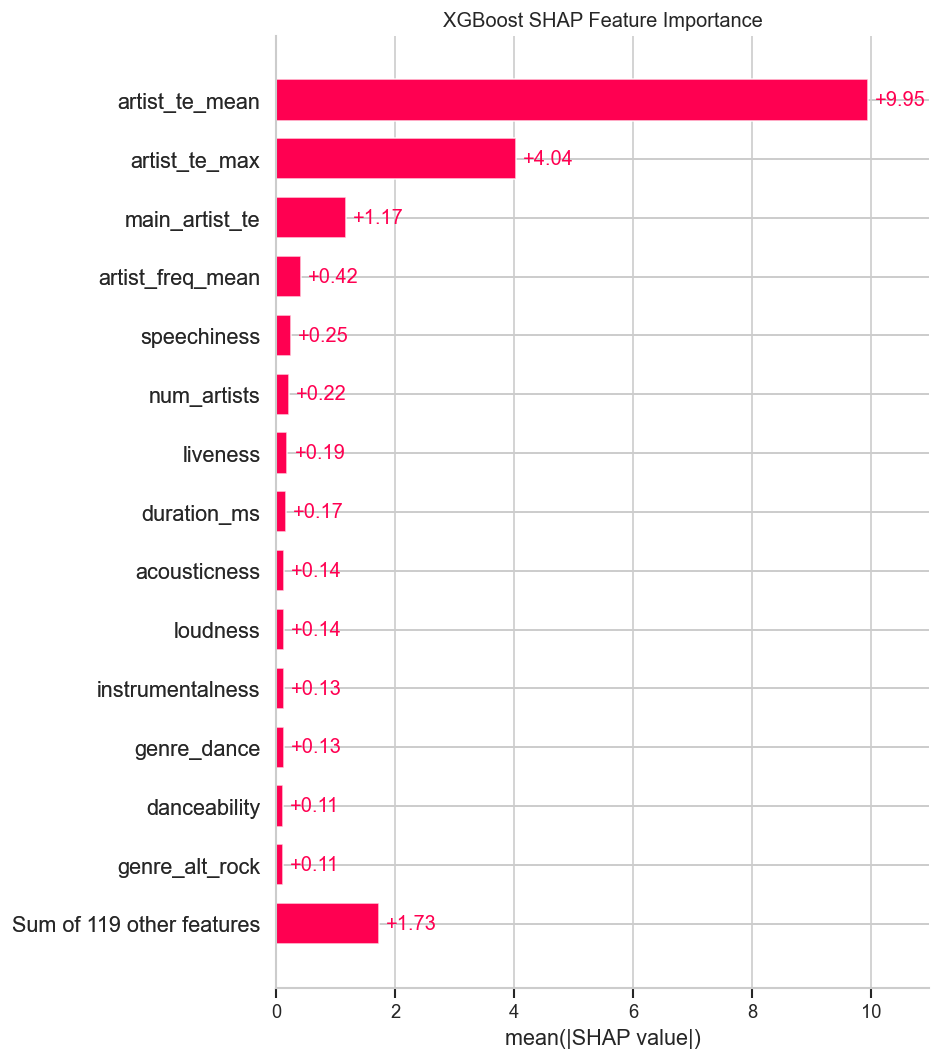

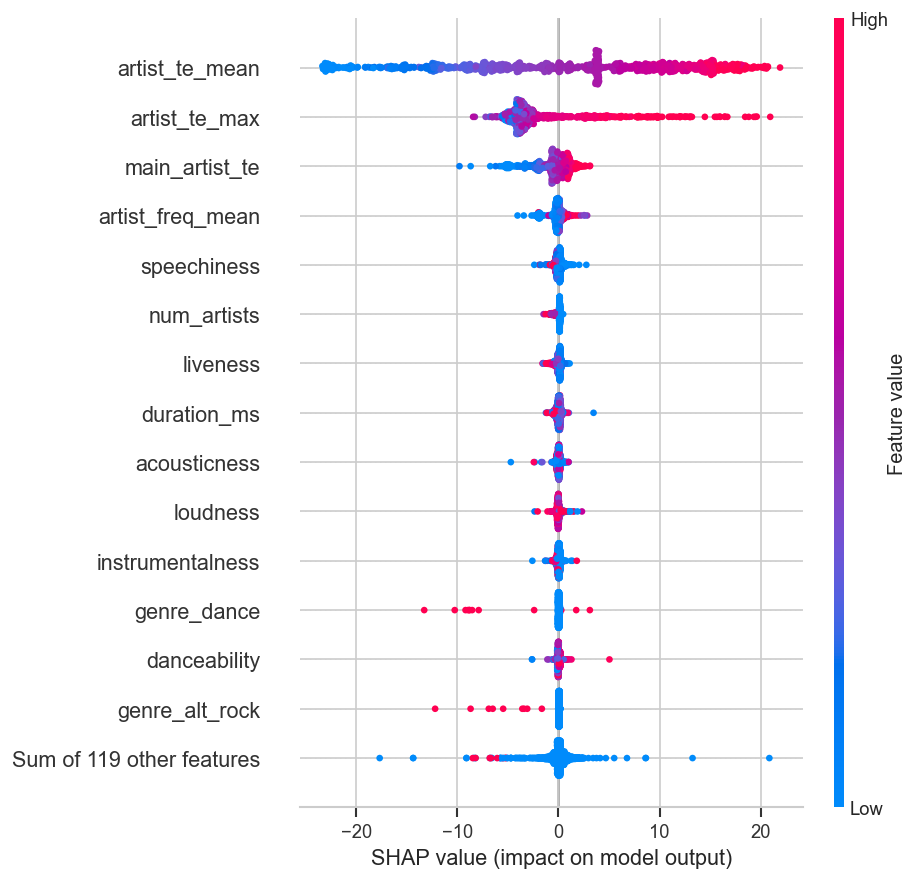

In [9]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('XGBoost SHAP Feature Importance')
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()



## 7.5 Local explanation for sample row

Sample original index: 15346
Track details:
 - track_id: 4Tbmg5W9EtxH4mAPPCmoZ5
 - artists: Jenevieve
 - track_name: Eternal
 - album_name: Blinding Lights
 - track_genre: chill
 - duration_ms: 160346
 - explicit: 0
 - duration (mm:ss): 2:40
True popularity: 0
XGBoost predicted popularity: 29.57

Top SHAP feature contributions (absolute):


artist_te_max       2.157123
loudness            0.670886
key                 0.589272
main_artist_te      0.502042
genre_chill         0.310540
speechiness         0.266450
artist_freq_mean    0.234051
num_artists         0.181462
liveness            0.156907
artist_te_mean      0.125988
dtype: float32

Local explanation for test row: 15346


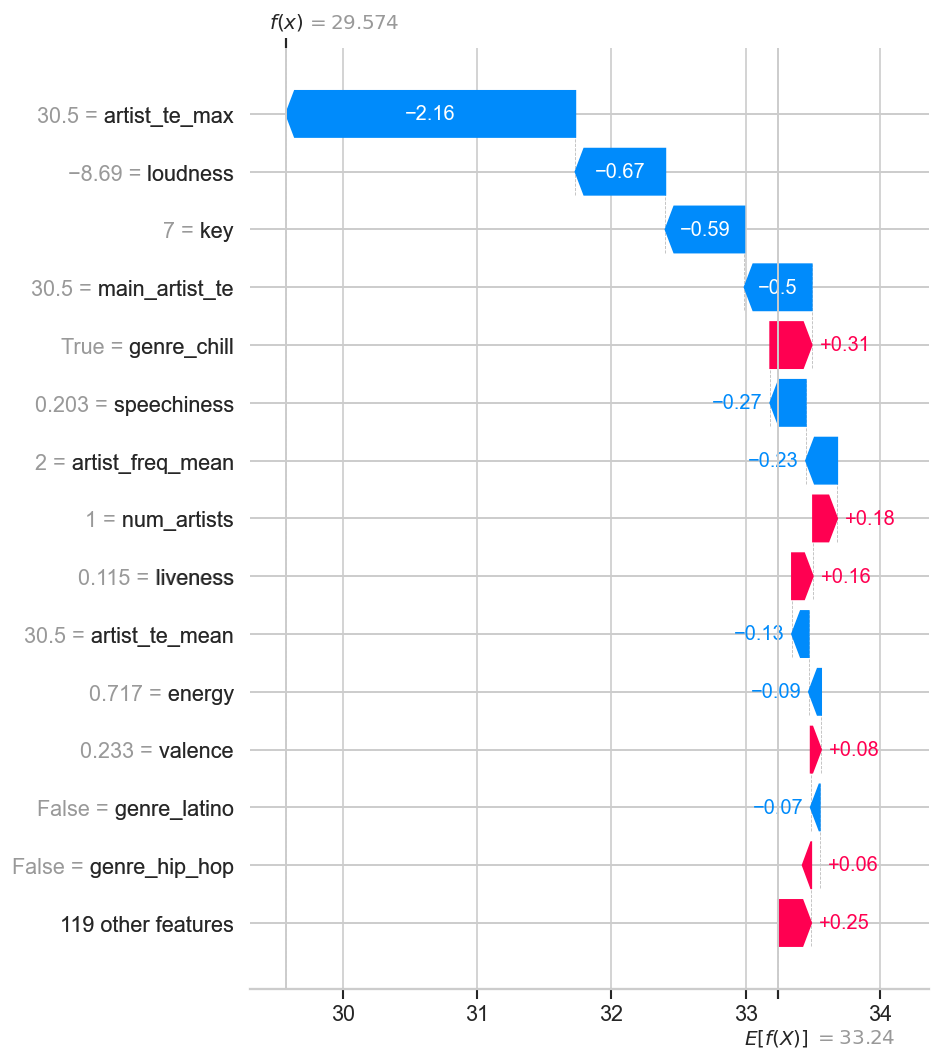

In [11]:
sample_row = shap_sample.index[0]
# mention details of the sample row
try:
    raw_row = X_test_raw.loc[sample_row]
except Exception:
    raw_row = df.loc[sample_row] if sample_row in df.index else None

print(f"Sample original index: {sample_row}")
if raw_row is not None:
    print("Track details:")
    for col in ['track_id', 'artists', 'track_name', 'album_name', 'track_genre', 'duration_ms', 'explicit']:
        if col in raw_row.index:
            print(f" - {col}: {raw_row[col]}")
    if 'duration_ms' in raw_row.index and pd.notna(raw_row['duration_ms']):
        dur_ms = int(raw_row['duration_ms'])
        m = dur_ms // 60000
        s = (dur_ms % 60000) // 1000
        print(f" - duration (mm:ss): {m}:{s:02d}")

# true and predicted popularity for this sample
true_pop = y_test.loc[sample_row] if sample_row in y_test.index else None
if sample_row in shap_sample.index:
    sample_df = shap_sample.loc[[sample_row]]
else:
    sample_df = shap_sample.iloc[[0]]

pred_pop = xgb_model.predict(sample_df)[0]
print(f"True popularity: {true_pop}")
print(f"XGBoost predicted popularity: {pred_pop:.2f}")

# show top absolute SHAP contributors for this instance
try:
    idx = list(shap_sample.index).index(sample_row)
    sample_shap = shap_values.values[idx]
    contribs = pd.Series(sample_shap, index=shap_sample.columns).abs().sort_values(ascending=False)
    print("\nTop SHAP feature contributions (absolute):")
    display(contribs.head(10))
except Exception:
    # fallback: use first row in shap_values if indexing fails
    sample_shap = shap_values.values[0]
    contribs = pd.Series(sample_shap, index=shap_sample.columns).abs().sort_values(ascending=False)
    print("\nTop SHAP feature contributions (absolute) [fallback]:")
    display(contribs.head(10))

print(f'Local explanation for test row: {sample_row}')
shap.plots.waterfall(shap_values[0], max_display=15, show=False)
plt.tight_layout()
plt.show()

## Main takeaway

The model is relying very heavily on artist-related features, much more than on audio features.

From the bar plot:

* artist_te_mean is by far the most important feature:
    If a song has multiple artists, this is the average of their target-encoding values. On average, how successful are the artists on this track?
* then artist_te_max: 
    This is the highest target-encoding value among all artists on the song. Is there at least one highly successful artist on this track?
* then main_artist_te:
    This is the average target value of the main artist based on past songs in the training data.

    So if the main artist usually has songs with high popularity, this value will be high.
    If the main artist usually has low-popularity songs, this value will be low.
* after that, everything else is much smaller

This means the model is learning that who made the song matters much more for predicted popularity than the song’s audio properties.

What that says about the data

It suggests that the dataset has a strong pattern like:

* songs from artists with historically high popularity tend to get predicted higher
* songs from artists with historically low popularity tend to get predicted lower

So the model is capturing artist popularity/history effect very strongly.

The SHAP analysis shows that artist-derived target encoding features dominate the model’s predictions. In particular, artist_te_mean and artist_te_max have substantially larger importance than all acoustic features, indicating that the model relies more on historical artist-level popularity patterns than on the musical characteristics of the track itself. Among the audio variables, features such as speechiness, loudness, acousticness, liveness, and tempo contribute only marginally. This suggests that, in the current dataset and feature setup, artist identity is a much stronger determinant of predicted popularity than audio content.

## 7.6 SHAP Dependence Plots

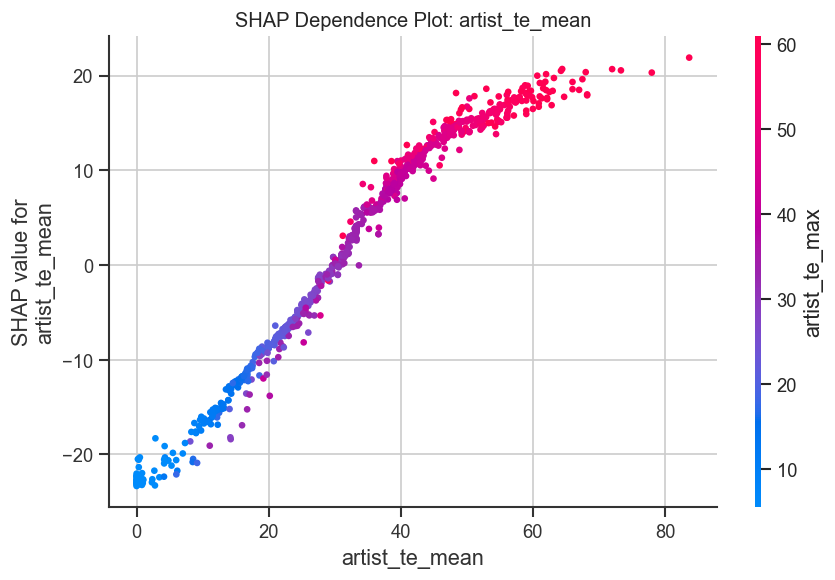

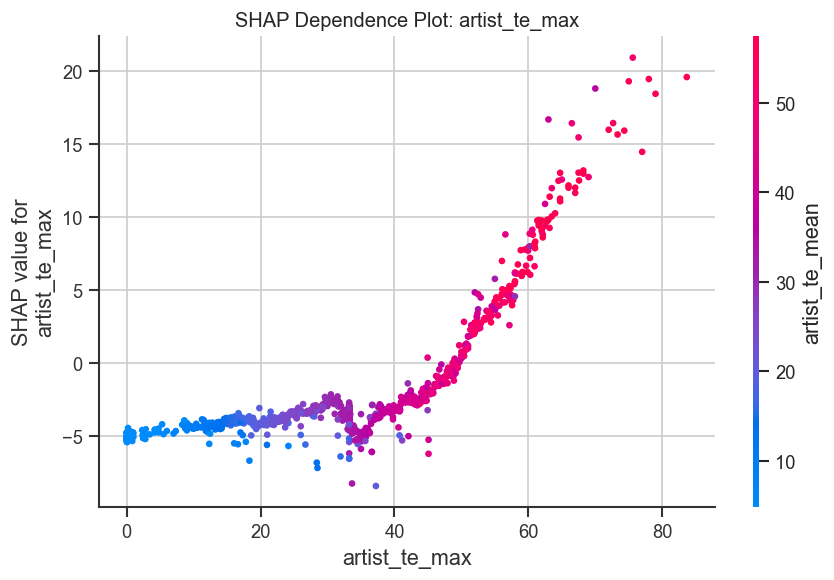

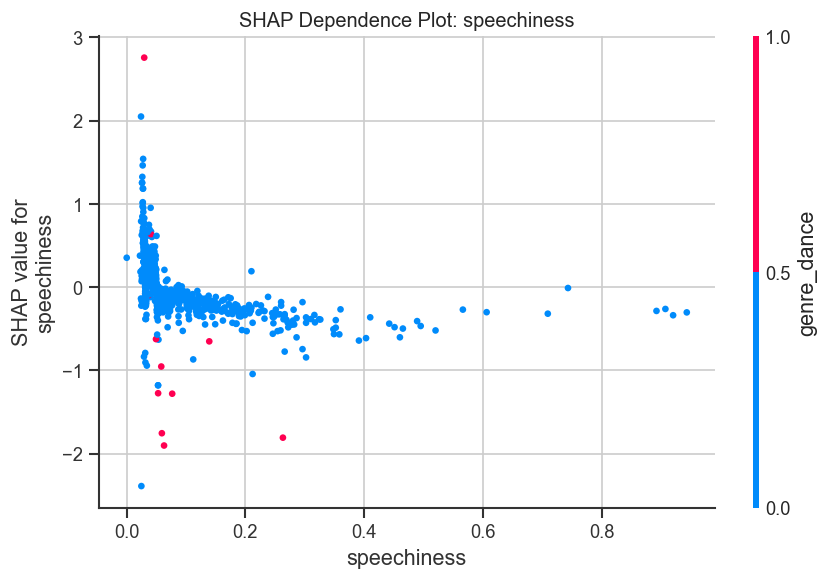

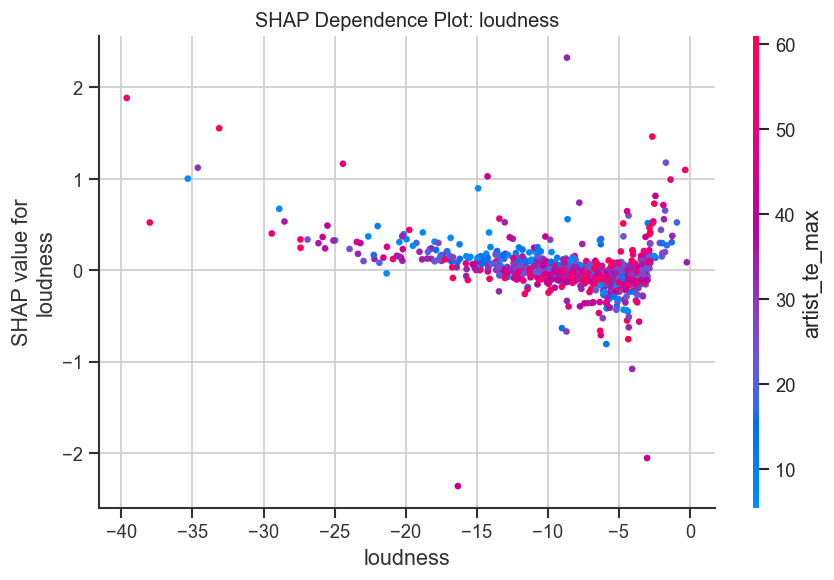

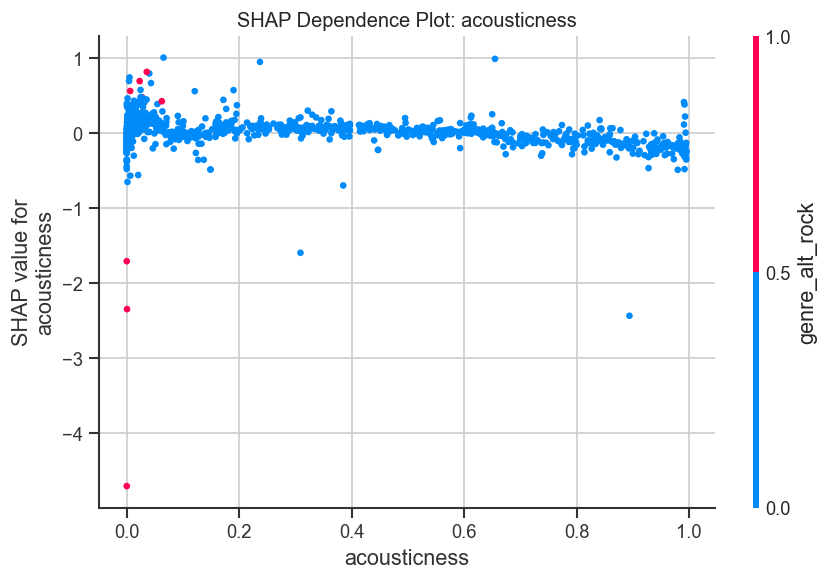

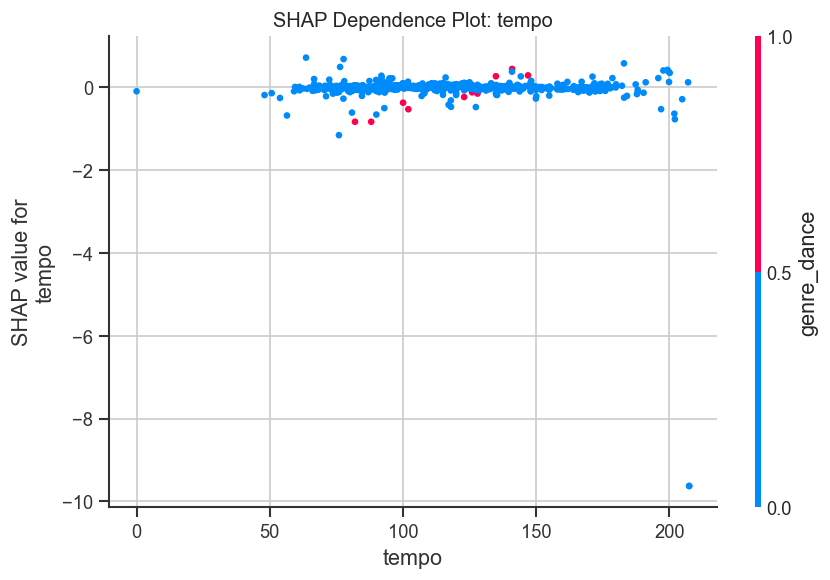

In [12]:
dependence_features = [
    'artist_te_mean',
    'artist_te_max',
    'speechiness',
    'loudness',
    'acousticness',
    'tempo',
]

for feature_name in dependence_features:
    shap.dependence_plot(
        feature_name,
        shap_values.values,
        shap_sample,
        interaction_index='auto',
        show=False,
    )
    plt.title(f'SHAP Dependence Plot: {feature_name}')
    plt.tight_layout()
    plt.show()


## 7.7 Predicted vs actual target for select observations and Local SHAP waterfall

In [14]:
xgb_predictions = pd.Series(predictions['xgboost'], index=X_test.index, name='predicted_popularity')

high_idx = xgb_predictions.idxmax()
low_idx = xgb_predictions.idxmin()
median_prediction = xgb_predictions.median()
medium_idx = (xgb_predictions - median_prediction).abs().idxmin()

selected_song_indices = {
    'high_predicted_popularity': high_idx,
    'medium_predicted_popularity': medium_idx,
    'low_predicted_popularity': low_idx,
}

selected_song_summary = pd.DataFrame([
    {
        'bucket': bucket,
        'track_name': X_test_raw.loc[idx, 'track_name'],
        'artists': X_test_raw.loc[idx, 'artists'],
        'genre': X_test_raw.loc[idx, 'track_genre'],
        'actual_popularity': y_test.loc[idx],
        'predicted_popularity': xgb_predictions.loc[idx],
    }
    for bucket, idx in selected_song_indices.items()
])

display(selected_song_summary)


,bucket,track_name,artists,genre,actual_popularity,predicted_popularity
0,high_predicted_popularity,Kiss Me More (feat. SZA),Doja Cat;SZA,dance,81,84.836052
1,medium_predicted_popularity,Nobody But Me,The Human Beinz,garage,60,31.913807
2,low_predicted_popularity,Treat You Better,RÜFÜS DU SOL,electro,0,-4.451326


Local SHAP waterfall: high_predicted_popularity


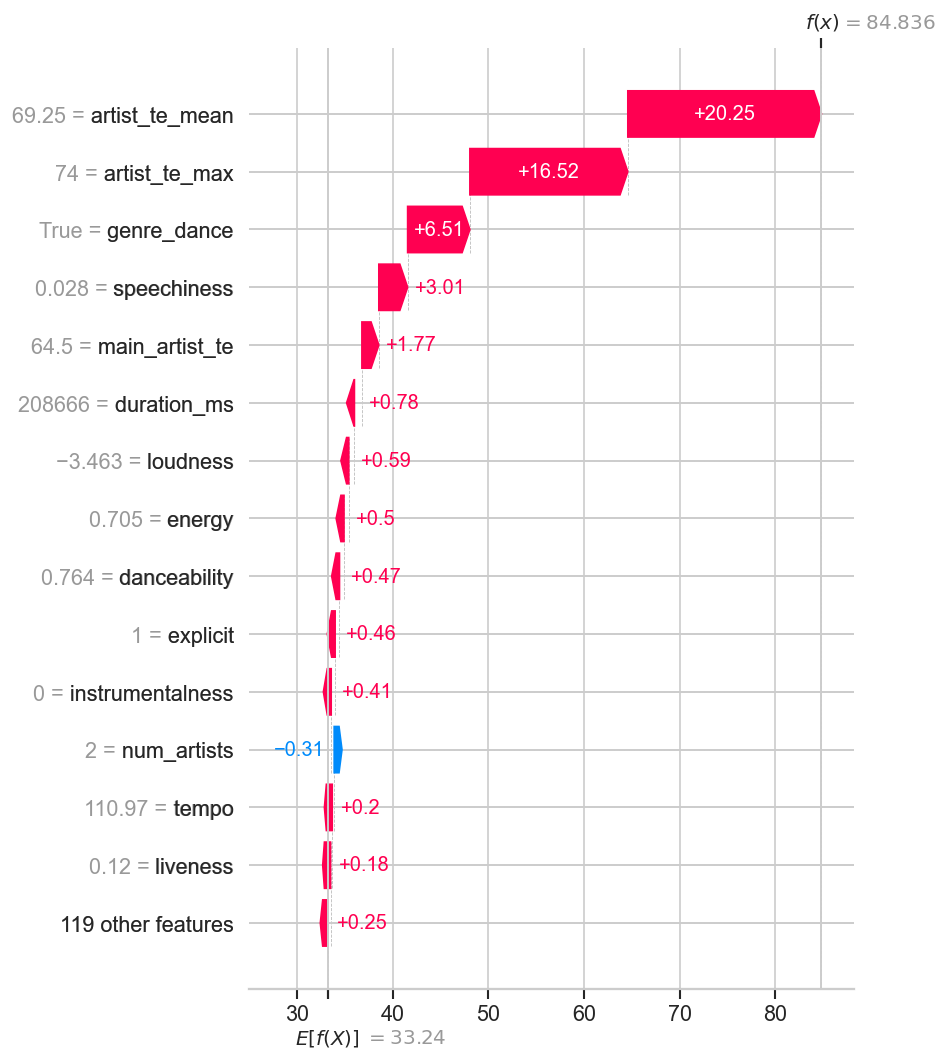

Local SHAP waterfall: medium_predicted_popularity


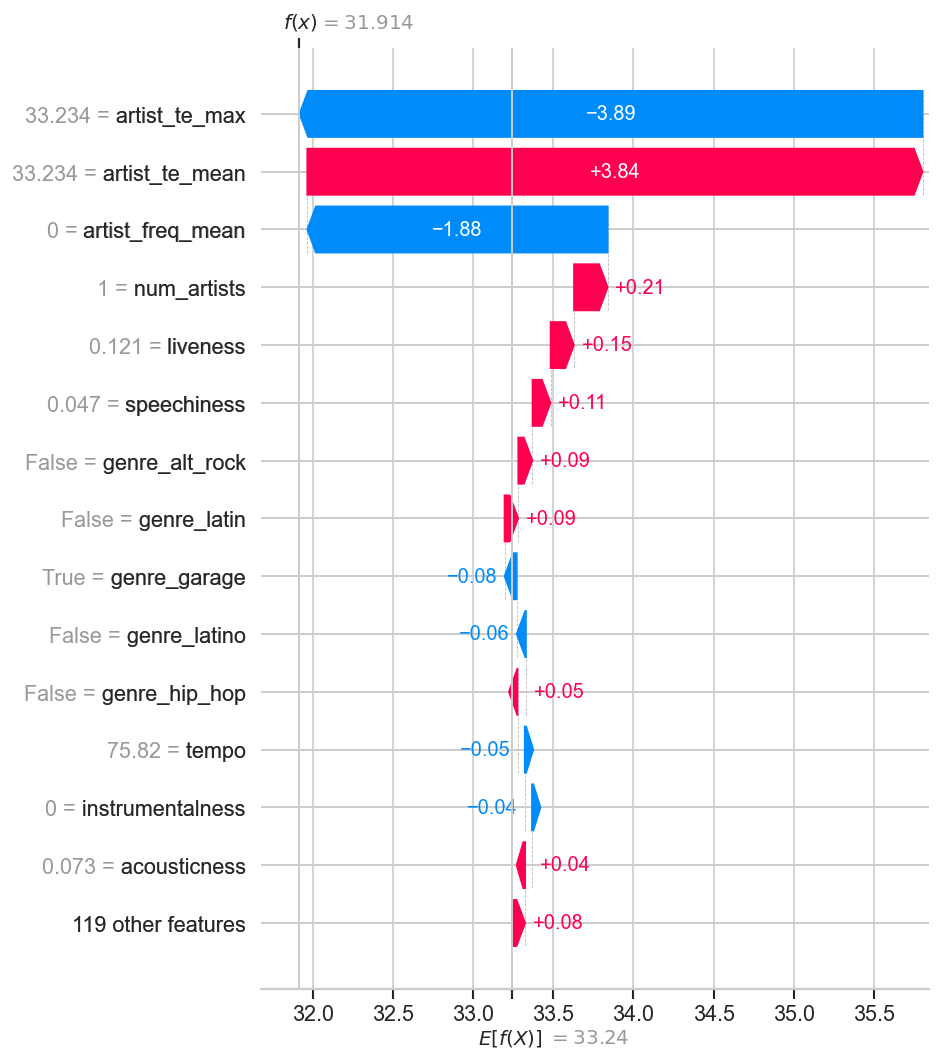

Local SHAP waterfall: low_predicted_popularity


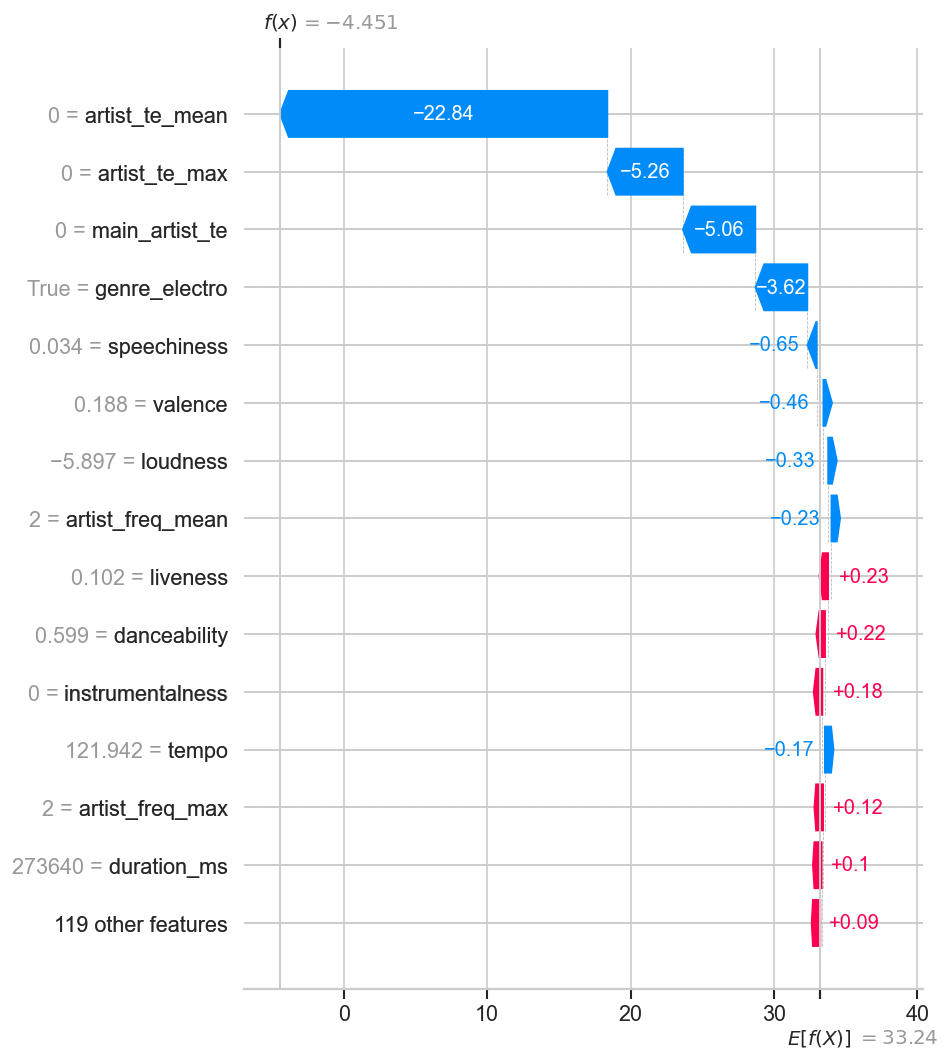

In [15]:
selected_feature_rows = X_test.loc[list(selected_song_indices.values())]
selected_shap_values = shap_explainer(selected_feature_rows)

for bucket, row_position in zip(selected_song_summary['bucket'], range(len(selected_feature_rows))):
    print(f'Local SHAP waterfall: {bucket}')
    shap.plots.waterfall(selected_shap_values[row_position], max_display=15, show=False)
    plt.tight_layout()
    plt.show()


## 7.8 Feature Group Importance

,feature_group,total_mean_abs_shap,avg_mean_abs_shap,feature_count,share_of_total
0,artist features,15.885653,2.647609,6,0.840862
1,audio features,1.564908,0.111779,14,0.082834
2,genre features,1.441536,0.012757,113,0.076304


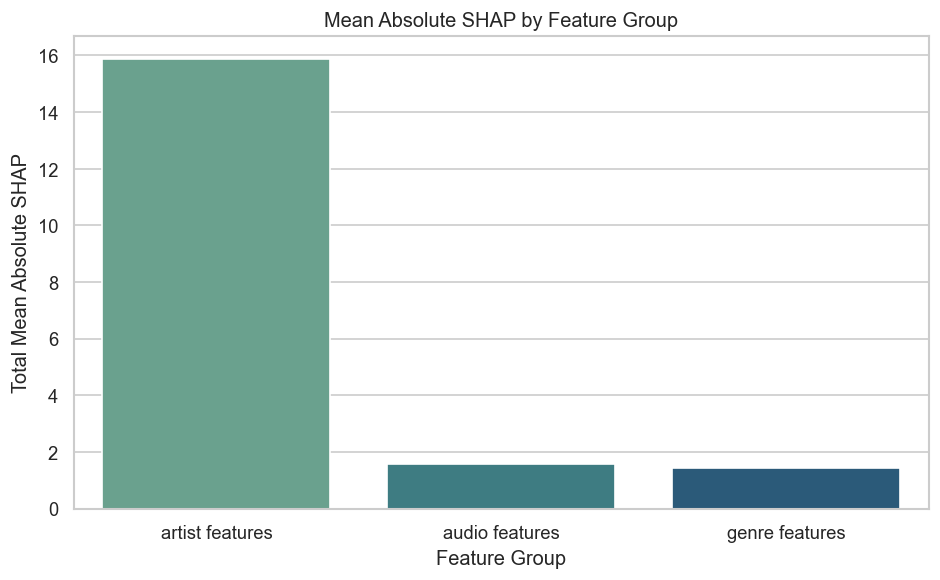

In [16]:
artist_feature_columns = [
    'main_artist_te',
    'num_artists',
    'artist_te_mean',
    'artist_te_max',
    'artist_freq_mean',
    'artist_freq_max',
]
genre_feature_columns = [column for column in X_train.columns if column.startswith('genre_')]
audio_feature_columns = [
    column for column in X_train.columns
    if column not in artist_feature_columns + genre_feature_columns
]

feature_group_lookup = {}
for column in artist_feature_columns:
    feature_group_lookup[column] = 'artist features'
for column in genre_feature_columns:
    feature_group_lookup[column] = 'genre features'
for column in audio_feature_columns:
    feature_group_lookup[column] = 'audio features'

group_shap_df = mean_abs_shap.copy()
group_shap_df['feature_group'] = group_shap_df['feature'].map(feature_group_lookup)
group_shap_summary = (
    group_shap_df.groupby('feature_group')['mean_abs_shap']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={
        'sum': 'total_mean_abs_shap',
        'mean': 'avg_mean_abs_shap',
        'count': 'feature_count',
    })
    .sort_values('total_mean_abs_shap', ascending=False)
    .reset_index()
)
group_shap_summary['share_of_total'] = (
    group_shap_summary['total_mean_abs_shap'] / group_shap_summary['total_mean_abs_shap'].sum()
)

display(group_shap_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=group_shap_summary,
    x='feature_group',
    y='total_mean_abs_shap',
    hue='feature_group',
    palette='crest',
    legend=False,
)
plt.title('Mean Absolute SHAP by Feature Group')
plt.xlabel('Feature Group')
plt.ylabel('Total Mean Absolute SHAP')
plt.tight_layout()
plt.show()


## 7.9 Running Model with different feature groups individually

In [17]:
def build_xgb_regressor():
    return XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
    )

ablation_feature_sets = {
    'full_model': X_train.columns.tolist(),
    'without_artist_features': [
        column for column in X_train.columns if column not in artist_feature_columns
    ],
    'audio_only_model': audio_feature_columns,
}

ablation_rows = []
ablation_predictions = {}

for ablation_name, feature_subset in ablation_feature_sets.items():
    ablation_model = build_xgb_regressor()
    ablation_model.fit(X_train[feature_subset], y_train)
    ablation_pred = ablation_model.predict(X_test[feature_subset])
    ablation_predictions[ablation_name] = ablation_pred

    ablation_mse = mean_squared_error(y_test, ablation_pred)
    ablation_rows.append({
        'model_variant': ablation_name,
        'feature_count': len(feature_subset),
        'RMSE': ablation_mse ** 0.5,
        'MSE': ablation_mse,
        'R2': r2_score(y_test, ablation_pred),
    })

ablation_metrics_df = pd.DataFrame(ablation_rows).sort_values('RMSE').reset_index(drop=True)
ablation_metrics_df


,model_variant,feature_count,RMSE,MSE,R2
0,full_model,133,13.863768,192.204056,0.539841
1,without_artist_features,127,16.334182,266.805511,0.361237
2,audio_only_model,14,18.700647,349.714203,0.162744


These results give a very clear story.

## Main conclusion

Your model’s predictive power comes **mostly from artist-related features**.
Audio and genre features add only some value.

---

## 1. SHAP group importance conclusion

From the SHAP grouping:

* **artist features:** 84.1% of total importance
* **audio features:** 8.3%
* **genre features:** 7.6%

This means the model is relying overwhelmingly on **artist-history signals**.

### What this says in simple words

The model is mainly learning:

> “Songs by artists who have historically performed well are more likely to be predicted as popular.”

rather than:

> “This song is popular because of its musical characteristics or genre.”

So the strongest signal in your dataset is **artist reputation / prior performance**, not the sound profile of the track.

---

## 2. Per-feature-group efficiency

The `avg_mean_abs_shap` values are also very important:

* **artist features:** 2.65 across only 6 features
* **audio features:** 0.111 across 14 features
* **genre features:** 0.012 across 113 features

This means artist features are not only the biggest group overall, but also **extremely strong per feature**.

### Interpretation

* each artist feature carries a lot of predictive information
* audio features are individually weak to moderate
* genre features are very diffuse and weak individually

So even though you have 113 genre columns, together they still contribute less than the artist group.

That suggests genre is not a major standalone driver in this setup.

---

## 3. Model ablation conclusion

Now the most important part is the model comparison.

### Full model

* RMSE = **13.86**
* R² = **0.54**

### Without artist features

* RMSE = **16.33**
* R² = **0.36**

### Audio-only model

* RMSE = **18.7**
* R² = **0.16**

---

## 4. What happens when artist features are removed?

When you remove artist features:

* RMSE gets much worse: **13.86 → 16.33**
* R² drops sharply: **0.54 → 0.36**

This is a major performance loss.

### Interpretation

Artist features are not just slightly useful.
They are the **main reason** the model performs well.

So the model’s ability to explain popularity is strongly tied to knowing the historical strength of the artist.

---

## 5. What do audio features contribute?

Compare:

* without artist features: R² = **0.36**
* audio only: R² = **0.16**

This suggests that once artist features are removed, the remaining non-artist features still retain some predictive signal, and audio features do explain part of popularity.

But their contribution is clearly much smaller than artist features.

### Interpretation

Audio properties matter, but they are **secondary predictors**.

The model can still learn something from them, but not nearly as much as from artist information.

---

## 6. What do genre features contribute?

Since:

* audio-only model has R² = **0.16**
* without artist features has R² = **0.36**

the gap is about **0.2 R²**

That suggests the extra non-audio features in the “without artist” model, especially genre, contribute **some additional value**.

Combined with SHAP:

* genre share is only **7.6%**
* average genre feature impact is tiny

### Interpretation

Genre helps a little at group level, but individual genre dummy variables are weak predictors.

So genre is likely a **supporting signal**, not a dominant one.

---

## 7. Strongest report-level inference

A very solid conclusion is:

> The model’s predictive performance is driven primarily by artist-derived features, which account for nearly 85% of total SHAP importance and whose removal causes a substantial drop in model accuracy. Audio features provide secondary predictive value, while genre features contribute only marginally. This indicates that the model is learning popularity largely through artist-level prior success rather than through the acoustic or stylistic characteristics of the track alone.

---

## 8. What this means conceptually

Your model is currently better at answering:

> “Will this song be popular given who the artists are?”

than:

> “Will this song be popular based on how it sounds?”

That is an important distinction.

---

## 9. Possible interpretation risk

There is also a caution here:

Because artist target-encoded features are so dominant, the model may be learning a kind of **artist prior bias**.
That is useful for prediction, but it reduces the role of music-content features.

So if your project goal is:

* **prediction accuracy**, this is acceptable and even expected
* **understanding musical drivers of popularity**, then this model is less suitable in its current form

---

## 10. Crisp conclusions you can write

You can state these:

1. **Artist-related features are the dominant predictive signal**, contributing about 85% of total SHAP importance.
2. **Removing artist features substantially degrades performance**, showing that the model depends strongly on artist-level historical information.
3. **Audio features have moderate but clearly smaller predictive value** than artist features.
4. **Genre features contribute the least**, despite having many encoded columns.
5. The full model is therefore learning **artist-driven popularity patterns more than content-driven popularity patterns**.

---

## 11. One extra nice inference

Because the full model R² is **0.54** and without artist it is **0.36**, you can say:

* roughly 2/3rd of the explained variance in the full model is tied to artist-related information

Not mathematically exact as a causal claim, but as an interpretation of the ablation, it is fair to say that **artist information accounts for a large share of the model’s explanatory power**.

---

## 12. Final simple summary

In simple words:

* **artist matters the most**
* **audio matters a little**
* **genre matters the least**
* your best model predicts popularity mainly from **who made the song**, not mainly from **how the song sounds**

A strong next step would be to build a **content-focused model without artist target encoding** if you want to study what musical characteristics drive popularity.
